# Q8. Which existing missense predictors are practical baselines, and how do they perform on the full validation dataset?

Evaluate **AlphaMissense, REVEL, SIFT4G, PolyPhen-2 HumVar and EVE** on every variant in Q1's frozen full `clinvar-test.vcf` from **6 July 2026**. This is development **validation**, with no separate untouched test set. PrimateAI-3D remains blocked on licensed data access.

[Implementation](src/q8_full.py) · [Method survey and sources](src/q8_catalog.json) · [Dependencies](../requirements.txt) · [README comparison](../README.md#method-comparison).

Run [Q1](Q1-clinvar-split.ipynb) first, then execute this notebook in cell order with the **Gamow** kernel. CPU only; no local model fitting, recalibration or variant uploads. Published score archives and indexed dbNSFP blocks are downloaded automatically when missing, verified and cached in `data/`. Acquisition can take tens of minutes. Historical September pilot notebooks, inputs and results remain in `results/archive/before_shared_july_snapshot/`.

In [1]:
from src import q8_full

## Frozen full inputs and leakage checks

Verify both full VCF checksums and rerun Q1's missense eligibility, gene, locus, group and sequence-context separation checks. Preserve every assigned split. Only validation chromosome/position/REF/ALT keys enter the score lookups; ClinVar outcomes are loaded afterwards from the full validation VCF.

The protocol fixes all five sources and score definitions before lookup. No sampling cap, balancing, threshold tuning or benign imputation is applied. Local leakage checks do not establish independence from external clinical calibration, model training or evolutionary sequences.

In [2]:
cohort = q8_full.prepare()

Verify ClinVar 2026-07-06, shared with Q0, and inherited group assignments.


5,000 sampled variants retained; 6 leakage check groups passed.


64,815 full-dataset variants; 0 sequence exclusions; 8 audit groups passed.
ClinVar 2026-07-06: all 17,927 full validation variants; 8 split/sequence audit groups passed. No training or sampling.


## AlphaMissense

Use the pinned **2023 GRCh38** archive. Match chromosome, position, REF and ALT exactly, removing only the `chr` prefix; take the maximum continuous `am_pathogenicity` across matching transcript annotations. Keep unmatched alleles unscored.

The core model uses population variation; released scores and thresholds use [ClinVar calibration](https://www.ebi.ac.uk/training/online/courses/alphafold/classifying-the-effects-of-missense-variants-using-alphamissense/understanding-pathogenicity-scores-from-alphamissense/). Calibration overlap is unresolved. [Published source and checksums](../data/README.md#q8-alphamissense-scores).

In [3]:
reports = {'AlphaMissense': q8_full.run_method('AlphaMissense', cohort)}

Reusing verified AlphaMissense archive.


  Read 20,000,000 score rows; retained 4,557 annotations.


  Read 40,000,000 score rows; retained 9,120 annotations.


  Read 60,000,000 score rows; retained 14,098 annotations.


AlphaMissense: 16,884/17,927 validation variants scored; 69.8 seconds.


## REVEL

Use **v1.3**, exact GRCh38 `grch38_pos`/REF/ALT matches, and the maximum continuous score across matching annotations. Missing GRCh38 positions have no GRCh37 fallback. REVEL's HGMD training variants and constituent tools may overlap ClinVar; no independence claim is made. [Published source and checksums](../data/README.md#q8-revel-scores).

In [4]:
reports['REVEL'] = q8_full.run_method('REVEL', cohort)

Reusing verified REVEL archive.


  Read 20,000,000 REVEL rows; retained 4,802 annotations.


  Read 40,000,000 REVEL rows; retained 8,332 annotations.


  Read 60,000,000 REVEL rows; retained 12,559 annotations.


  Read 80,000,000 REVEL rows; retained 17,458 annotations.


REVEL: 17,720/17,927 validation variants scored; 106.1 seconds.


## SIFT4G, PolyPhen-2 HumVar and EVE

Retrieve exact validation alleles from **dbNSFP4.9a** using its Tabix index and verified HTTP byte ranges. Full-validation annotations have their own manifest; raw block caches are shared with earlier lookups. Metadata MD5s, data ETag/generation, byte ranges, block SHA-256 checksums and BGZF CRCs are checked. The full 39.5 GB database MD5 is not recomputed.

- **SIFT4G:** `1 - SIFT4G_score`.
- **PolyPhen-2:** `Polyphen2_HVAR_score` (HumVar).
- **EVE:** continuous `EVE_score`, without confidence-category filtering.

Take the maximum damaging-direction score across matching annotations; preserve every missing score and exact-allele mismatch. SIFT4G/EVE evolutionary-data overlap and PolyPhen-2 clinical-training overlap are unaudited. [Acquisition and sources](../data/README.md#q8-sift4g-polyphen-2-and-eve-scores).

In [5]:
reports.update(q8_full.run_remaining(cohort))

Reusing verified dbNSFP score extraction offline.


Reusing verified dbNSFP score extraction offline.


SIFT4G: 16,917/17,927 validation variants scored; 13.0 seconds.


Reusing verified dbNSFP score extraction offline.


PolyPhen-2: 16,430/17,927 validation variants scored; 12.4 seconds.


Reusing verified dbNSFP score extraction offline.


EVE: 9,284/17,927 validation variants scored; 5.5 seconds.


## PrimateAI-3D access

The [official release](https://github.com/Illumina/PrimateAI-3D) requires a signed license agreement and an emailed download link. No licensed score file or approved link is available. Record this blocker for the current full cohort; dbNSFP's original PrimateAI scores cannot substitute for PrimateAI-3D.

In [6]:
primate_access = q8_full.report_primate_access(cohort)

**PrimateAI-3D remains blocked:** PrimateAI-3D has not been run: Illumina requires a signed license agreement and supplies the score/model download link by email. No approved link or licensed score file was provided. The original PrimateAI scores in dbNSFP are a different model and are not substituted.

## Validation performance and coverage

Each method's AUROC and average precision use its scored validation subset. Percentile **95% intervals** resample whole Q1 components **1,000 times**, with **seed 42**; members stay together before restricting to scored variants. Missing predictions are retained in coverage denominators. Intervals do not correct external-data overlap or development-selection bias.

Each method writes raw scores, matched annotations, labeled validation predictions, coverage, metrics and completion provenance under [results/q8/full/](results/q8/full/). [Artifact descriptions](results/README.md#q8-artifacts-missense-survey-and-external-predictors).

| Method | Scored / validation | AUROC [95% CI] | Average precision [95% CI] |
| --- | --- | --- | --- |
| AlphaMissense | 16,884 / 17,927 | 0.962 [0.956, 0.967] | 0.940 [0.923, 0.951] |
| REVEL | 17,720 / 17,927 | 0.974 [0.970, 0.978] | 0.958 [0.945, 0.968] |
| SIFT4G | 16,917 / 17,927 | 0.878 [0.865, 0.890] | 0.772 [0.734, 0.804] |
| PolyPhen-2 | 16,430 / 17,927 | 0.894 [0.883, 0.905] | 0.822 [0.781, 0.852] |
| EVE | 9,284 / 17,927 | 0.909 [0.889, 0.925] | 0.916 [0.889, 0.935] |

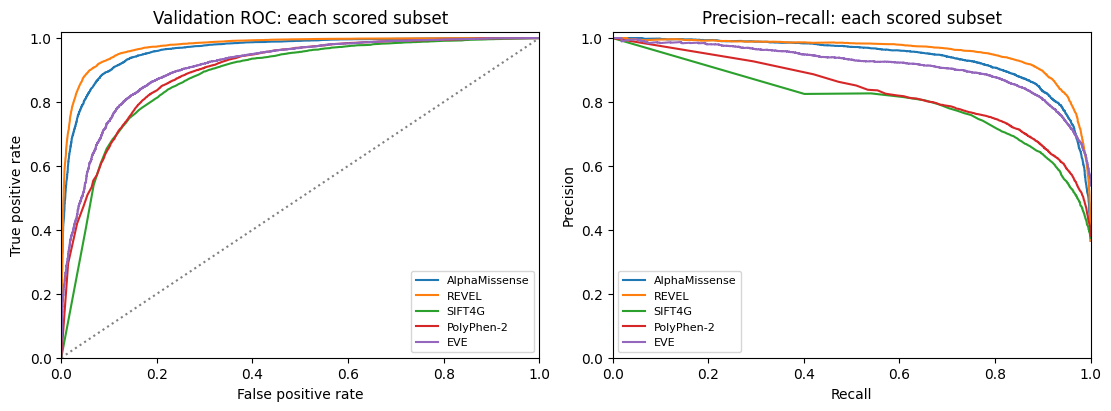

In [7]:
q8_full.show_results(reports)

## Conclusion

Refresh the README from verified exports, then compare methods on the same variants scored by every currently available method. Full-cohort results remain separate from archived pilot evaluations.

In [8]:
comparison_result = q8_full.conclude(reports, primate_access)

**Comparison on the same variants as the README**

| Method | Shared variants | AUROC [95% CI] | Average precision [95% CI] |
| --- | --- | --- | --- |
| AlphaMissense | 8817 | 0.961 [0.953, 0.968] | 0.967 [0.957, 0.975] |
| REVEL | 8817 | 0.972 [0.966, 0.978] | 0.976 [0.967, 0.984] |
| SIFT4G | 8817 | 0.887 [0.872, 0.901] | 0.881 [0.853, 0.906] |
| PolyPhen-2 | 8817 | 0.900 [0.887, 0.913] | 0.903 [0.879, 0.925] |
| EVE | 8817 | 0.911 [0.893, 0.928] | 0.921 [0.899, 0.940] |

**Conclusion.** Five published predictors provide scores for **51.8%–98.8%** of the **17,927** full validation variants. The shared-subset table supports direct comparison; missing-score coverage remains a limitation. PrimateAI-3D is blocked on licensed data access. These are development results against ClinVar, with unresolved clinical-training/calibration and evolutionary-data overlap. They do not establish independent clinical validity.